In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms as T
import cv2

In [ ]:
import torchvision

pre-trained Faster-RCNN model

In [ ]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True) # fpn=> feature pyramid network
model.eval()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
# define class label
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

In [ ]:
def get_prediction(img_path, threshold):
  img = Image.open(img_path) # load image
  transform = T.Compose([T.ToTensor()]) # transform the image
  img = transform(img)
  pred = model([img])# get pred

  # extract data
  pred_class = [COCO_INSTANCE_CATEGORY_NAMES[i] for i in list(pred[0]['labels'].numpy())]
  pred_boxes = [[(i[0], i[1]), (i[2], i[3])] for i in list(pred[0]['boxes'].detach().numpy())] # coordinate extrat
  pred_score = list(pred[0]['scores'].detach().numpy()) # confidence score
  pred_t = [pred_score.index(x) for x in pred_score if x > threshold][-1] # threshold
  pred_boxes = pred_boxes[:pred_t+1]# keep prediction with confi score greater than threshold
  pred_class = pred_class[:pred_t+1]
  return pred_boxes, pred_class


In [ ]:
def object_detection_api(img_path, threshold=0.5, rect_th=1, text_size=1, text_th=1):
  boxes, pred_cls = get_prediction(img_path, threshold) # get prediction
  img = cv2.imread(img_path) # read image
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert to RGB

  for i in range(len(boxes)):
    box = boxes[i]
    pt1 = (int(box[0][0]),int(box[0][1]))
    pt2 = (int(box[1][0]),int(box[1][1]))
    cv2.rectangle(img, pt1, pt2, color=(0,255,0), thickness=rect_th)
    cv2.putText(img, pred_cls[i], (pt1[0], pt1[1]-5), cv2.FONT_HERSHEY_SIMPLEX, text_size, (255,0,0),thickness=text_th)
  plt.figure(figsize=(10,20)) # display the output image
  plt.imshow(img)
  plt.xticks([])
  plt.yticks([])
  plt.show()

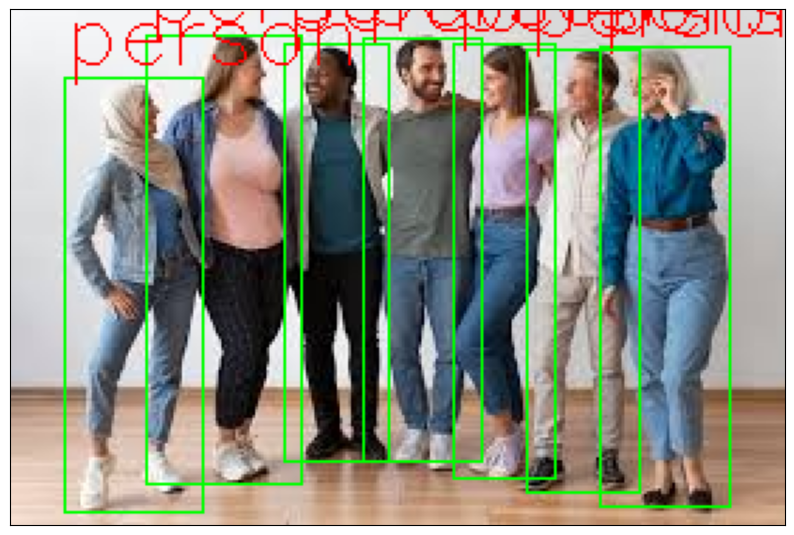

In [ ]:
object_detection_api('/content/people1.jpg', threshold = 0.8)

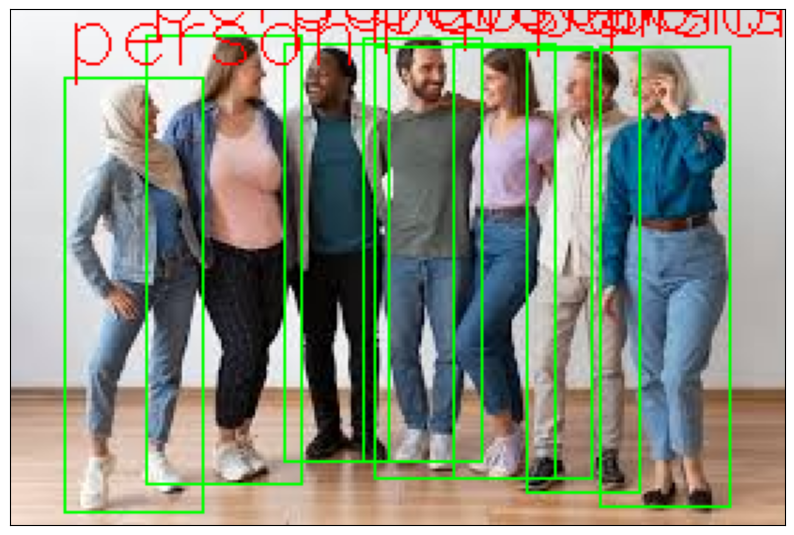

In [ ]:
object_detection_api('/content/people1.jpg', threshold = 0.5)

In [ ]:
object_detection_api('/content/cars.jpg', threshold = 0.8)

In [ ]:
object_detection_api('/content/girl_bag.jpg', threshold = 0.8)